# EDA on Subject One

We are focusing on analysing subject one and creating a baseline model

In [1]:
%load_ext autoreload
%autoreload 2

In [70]:
# All the imports for this notebook
from har_utils.data import get_subject
from har_utils.config import FILE_NAME_SUFFIX
import har_utils.visualization as viz
from har_utils.preprocessing import (
    do_sanity_check, 
    preprocessing_pipeline,
    get_shoulder_width
)
from har_utils.analysis import compare_feature_description
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
# I am just loading the first file to observe the data
subject1 = get_subject(FILE_NAME_SUFFIX[0])

print(subject1.shape)
subject1.head()

(76456, 35)


,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,right_ear_y,...,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y,Action Label
frame_id,,,,,,,,,,,,,,,,,,,,,
0,624.0,258.25,628.0,249.50,625.0,249.750,650.5,252.250,667.5,249.125,...,441.00,656.5,535.0,724.0,528.0,634.5,616.5,746.5,612.0,Walking
1,618.0,260.00,621.5,251.25,618.5,251.625,644.0,254.375,660.5,251.125,...,440.00,651.0,533.5,720.0,526.5,627.5,616.0,746.0,610.5,Walking
2,611.5,260.50,615.0,252.00,613.0,252.250,637.0,256.000,656.5,252.625,...,441.00,644.5,533.0,715.5,525.5,625.5,616.5,746.0,609.5,Walking
3,604.0,261.00,608.0,252.50,605.5,252.750,630.5,256.000,648.5,252.875,...,443.00,639.0,535.0,710.5,525.5,623.0,618.0,745.5,608.0,Walking
4,598.0,260.00,602.5,252.00,600.0,252.000,623.0,256.750,642.5,253.125,...,444.25,634.5,539.0,703.0,525.5,620.5,619.0,742.5,605.5,Walking


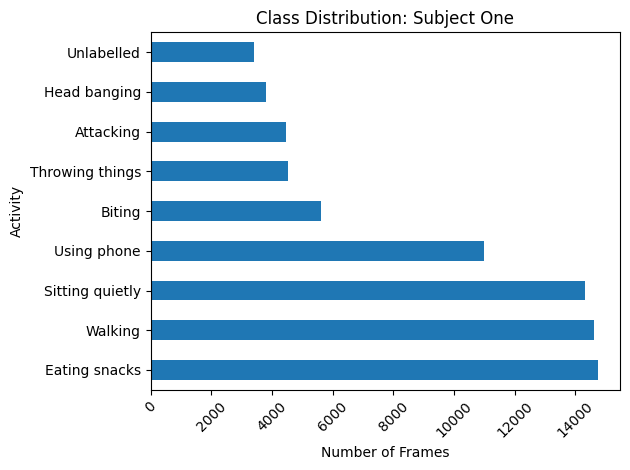

In [48]:
# Class Distribution Bar Graph - Subject One
viz.plot_class_distribution(subject1, "Subject One")

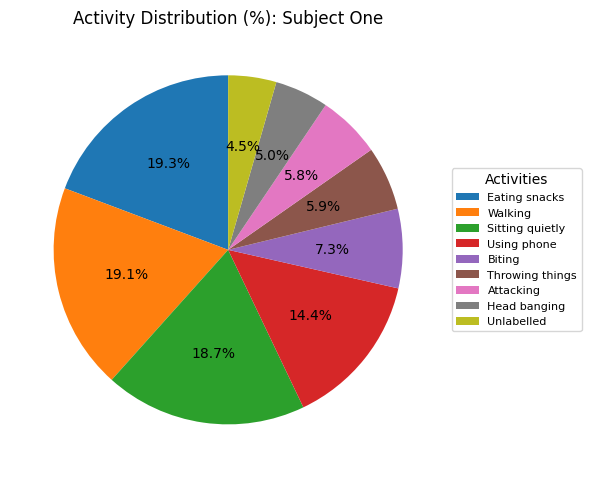

In [49]:
viz.plot_percentage_distribution(subject1, "Subject One")

In [39]:
# Let's do a sanity check
# Check for NaNs, Infs, zero-variance rows and label integrity.
do_sanity_check(subject1, "Subject One")


____________________________________________________________

               Sanity Check - Subject One
____________________________________________________________

NaN counts:
  Action Label: 3406

Inf counts:


In [42]:
subject1_norm = preprocessing_pipeline(subject1)

Total Number of Bad Frames where shoulder widht was less than 10: 1377


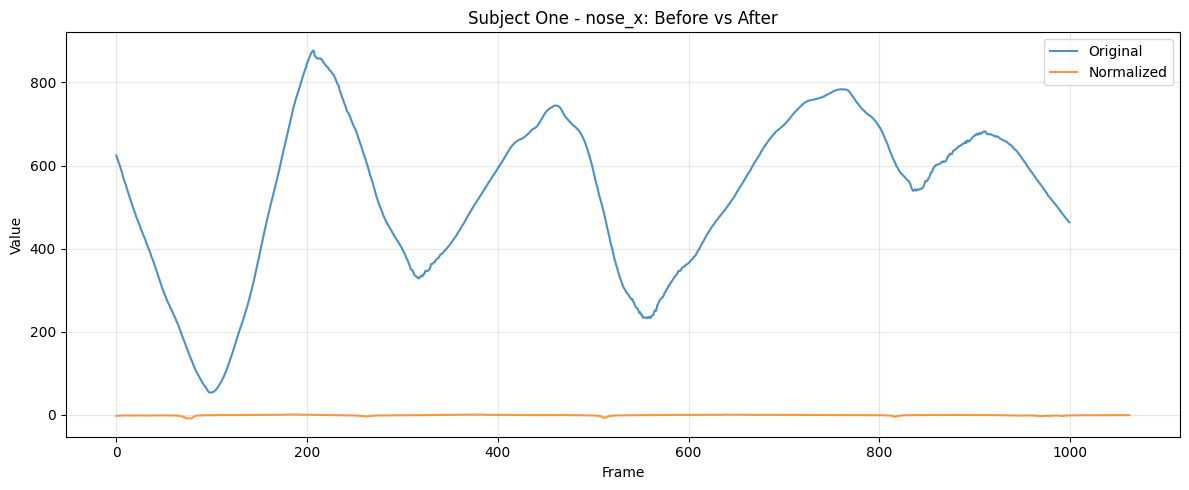

In [50]:
# Compare features between data before and after skelton normalization
viz.plot_compare_feature(
    subject1,
    subject1_norm,
    "nose_x",
    "Subject One",
    start=0,
    end=1000
)

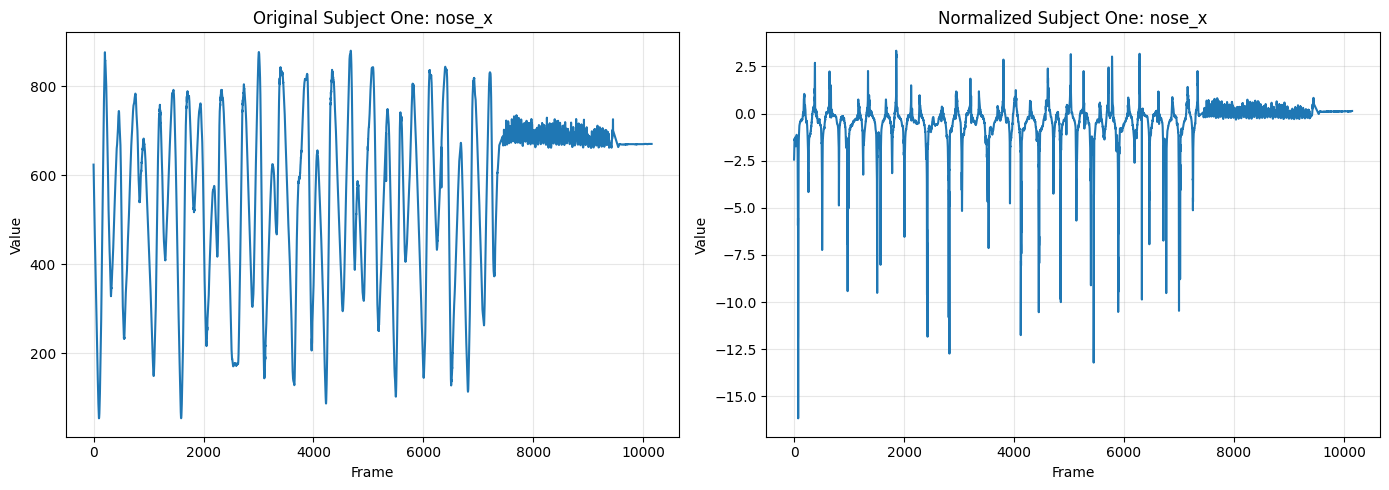

In [52]:
viz.plot_compare_feature_side_by_side(
    subject1,
    subject1_norm,
    "nose_x",
    "Subject One",
    start=0,
    end=10000)

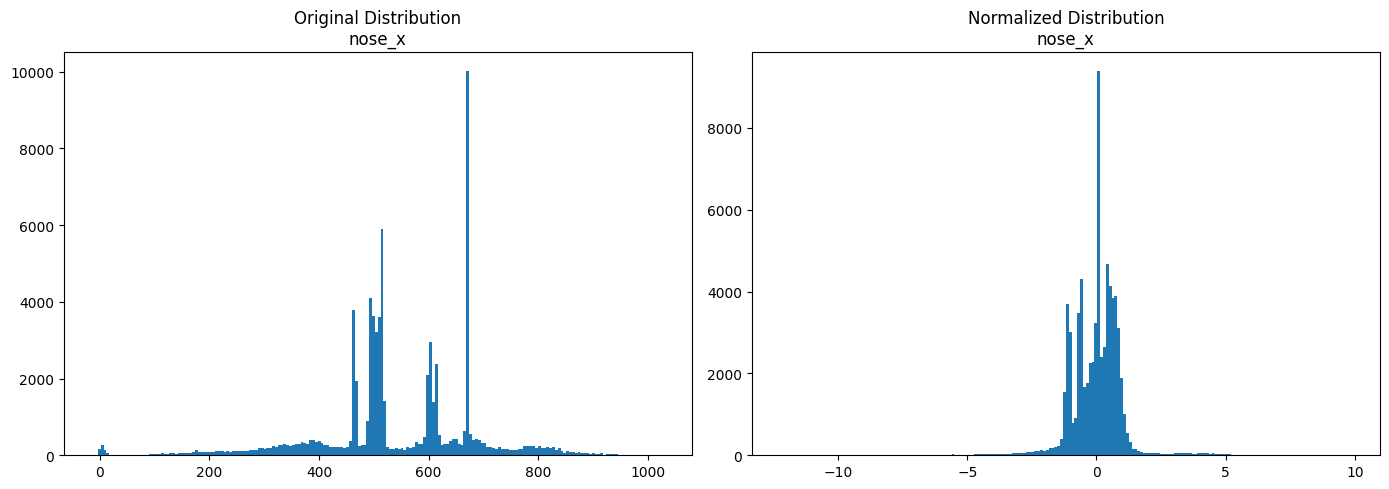

In [57]:
viz.plot_compare_histograms(
    subject1,
    subject1_norm,
    "nose_x",
    bins=200
)

In [58]:
compare_feature_description(subject1, subject1_norm, "nose_x")

Original
count    76456.000000
mean       542.463043
std        145.670475
min        -13.562500
25%        485.000000
50%        515.000000
75%        664.500000
max       1028.000000
Name: nose_x, dtype: float64

Normalized
count    71673.000000
mean        -0.010168
std          1.054087
min        -12.235954
25%         -0.600138
50%          0.114294
75%          0.530173
max          9.868396
Name: nose_x, dtype: float64


In [59]:
# Getting the shoulder_width from not normalizaed dataset
shoulder_width = get_shoulder_width(subject1)
print(shoulder_width.describe())

count    76456.000000
mean        53.050572
std         21.223071
min          0.500000
25%         42.735378
50%         51.924224
75%         59.588694
max        210.690086
dtype: float64


In [46]:
print(shoulder_width.nsmallest(20))

frame_id
37907    0.500000
58585    0.515388
27276    0.559017
37908    0.559017
75400    0.559017
58875    0.625000
58874    0.750000
37906    0.901388
76423    1.000000
37905    1.118034
27277    1.520691
6326     1.546165
58583    1.581139
75579    1.677051
76096    1.677051
75951    1.802776
75949    1.952562
37909    2.015564
42246    2.061553
75580    2.061553
dtype: float64


In [47]:
(shoulder_width < 10).sum()

np.int64(1377)

In [48]:
((shoulder_width < 10).sum() / len(shoulder_width)) * 100

np.float64(1.8850102669404518)

In [71]:
bad_frames = shoulder_width < 10
bad_counts = subject1.loc[bad_frames, 'Action Label'].value_counts()
total_counts = subject1['Action Label'].value_counts()
bad_ratio = (
    bad_counts / total_counts * 100
).sort_values(ascending=False)

print(bad_ratio)

Action Label
Attacking          7.225951
Walking            6.084873
Throwing things    3.377483
Using phone        0.109290
Biting                  NaN
Eating snacks           NaN
Head banging            NaN
Sitting quietly         NaN
Name: count, dtype: float64


In [72]:
subject1_norm['nose_x'].abs().sort_values(ascending=False).head(20)

frame_id
64438    12.235954
64443    11.139520
27004    10.345590
27006    10.302181
46139     9.868396
27016     9.825435
65585     9.394122
27005     9.385227
64437     9.361339
64444     9.328960
27015     9.237879
65586     8.966855
46134     8.885182
65584     8.746482
26428     8.741536
27002     8.741080
40774     8.629110
46138     8.612484
27003     8.592929
65583     8.573554
Name: nose_x, dtype: float64

In [73]:
subject1_norm.describe()

,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,right_ear_y,...,right_hip_x,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y
count,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,...,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000
mean,-0.010168,-3.488206,0.007530,-3.661544,-0.149160,-3.605351,-0.122574,-3.698561,-0.459081,-3.536666,...,-0.169742,-0.695129,1.047692,-0.551004,0.717444,0.077830,1.246635,0.529583,1.072709,0.803641
std,1.054087,5.004624,1.058971,5.032990,1.060749,5.050616,0.875914,4.984450,0.907949,5.035377,...,0.234502,4.197690,0.800259,3.630657,0.763920,3.893378,1.205869,3.527123,1.270625,3.643793
min,-12.235954,-58.301732,-12.769703,-59.135542,-12.739491,-59.124713,-12.024468,-59.124713,-11.410153,-59.254658,...,-1.559122,-42.556799,-3.690695,-34.925130,-3.582203,-36.016263,-5.664706,-30.438221,-6.780719,-30.316953
25%,-0.600138,-4.081120,-0.593545,-4.240794,-0.714815,-4.188049,-0.634340,-4.277156,-0.878132,-4.145088,...,-0.305104,-2.272239,0.459764,-2.970201,0.087120,-2.389619,0.627518,-1.588906,0.275323,-1.374930
50%,0.114294,-2.061392,0.177917,-2.260707,-0.061696,-2.160360,0.045043,-2.310326,-0.337778,-2.032123,...,-0.257098,0.559975,1.090885,0.161890,0.805111,0.874045,0.943913,0.482100,0.816754,1.098549
75%,0.530173,-0.297336,0.518558,-0.433730,0.397667,-0.354181,0.312500,-0.537859,-0.059003,-0.316199,...,-0.162122,2.049675,1.735373,1.494788,1.167282,2.753054,1.615739,2.536761,1.401255,2.602044
max,9.868396,7.568302,10.456879,6.802773,10.366343,6.849168,9.868396,7.266730,10.366343,6.941960,...,1.087500,23.458836,5.534146,30.742964,7.006626,30.371799,9.476537,36.913595,12.806143,37.563263


In [55]:
subject1_norm['left_ankle_y'].abs().nlargest(10)

frame_id
1573     36.913595
79       36.078262
39150    34.793907
39148    34.017028
37500    33.864419
80       32.952189
37499    31.454080
41263    30.865738
1572     30.522210
3814     30.438221
Name: left_ankle_y, dtype: float64

In [56]:
shoulder_width.loc[1573]

np.float64(10.776855988645297)

In [57]:
sub_one_norm_ds.isna().sum()

nose_x              0
nose_y              0
left_eye_x          0
left_eye_y          0
right_eye_x         0
right_eye_y         0
left_ear_x          0
left_ear_y          0
right_ear_x         0
right_ear_y         0
left_shoulder_x     0
left_shoulder_y     0
right_shoulder_x    0
right_shoulder_y    0
left_elbow_x        0
left_elbow_y        0
right_elbow_x       0
right_elbow_y       0
left_wrist_x        0
left_wrist_y        0
right_wrist_x       0
right_wrist_y       0
left_hip_x          0
left_hip_y          0
right_hip_x         0
right_hip_y         0
left_knee_x         0
left_knee_y         0
right_knee_x        0
right_knee_y        0
left_ankle_x        0
left_ankle_y        0
right_ankle_x       0
right_ankle_y       0
Action Label        0
dtype: int64

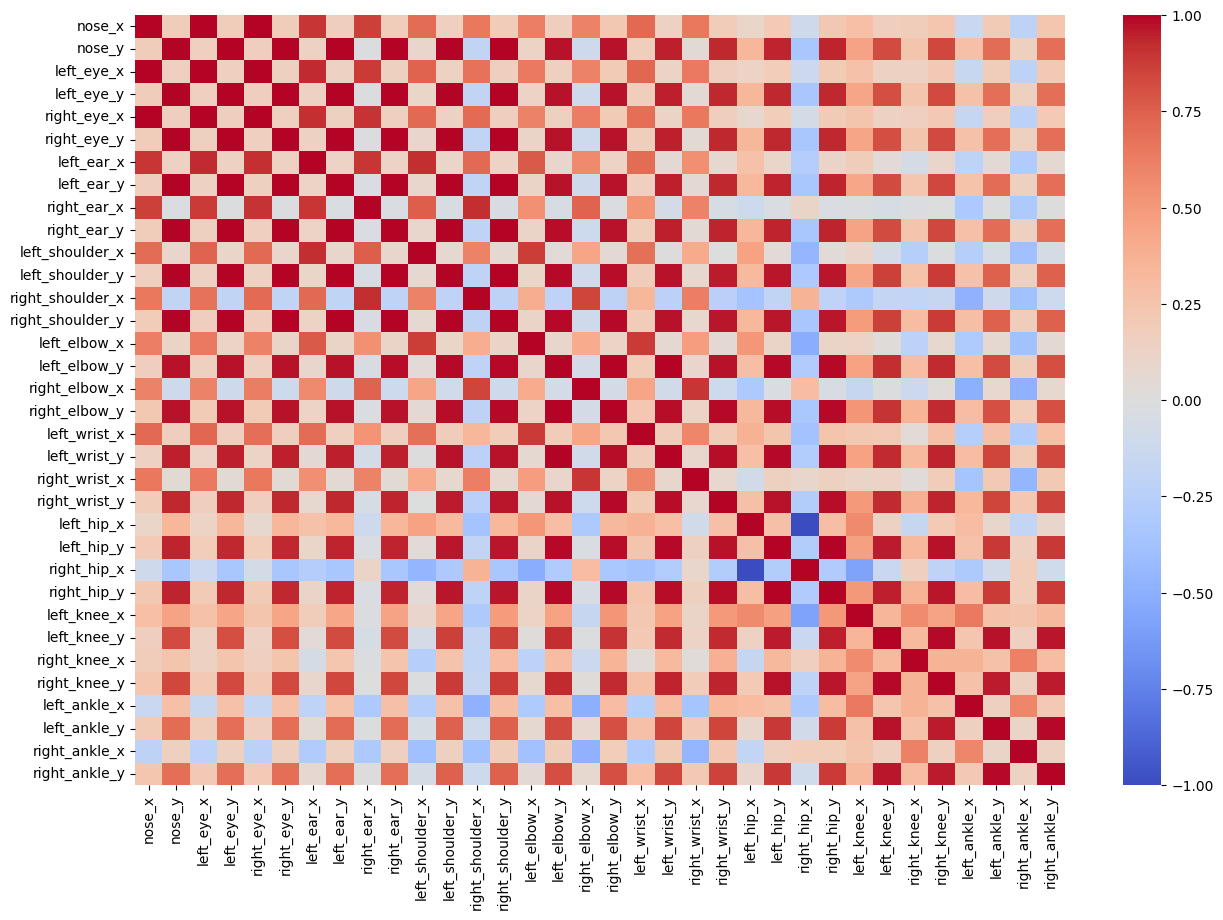

In [58]:
plt.figure(figsize=(15,10))
sns.heatmap(
    sub_one_norm_ds.select_dtypes(include='number').corr(),
    cmap='coolwarm'
)
plt.show()

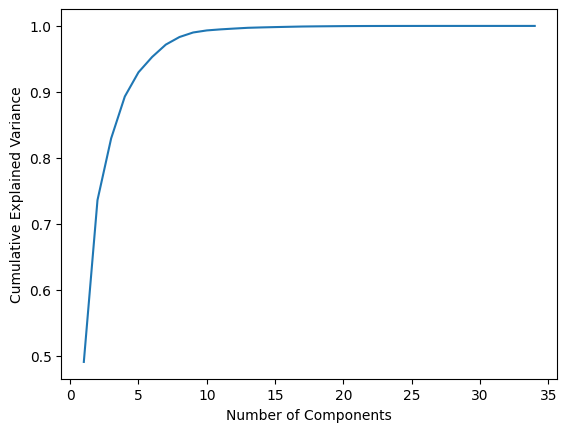

In [59]:
# Lets do some PCA
# PCA やろう
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = sub_one_norm_ds.drop(columns=['Action Label'])
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_.cumsum()
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [60]:
X = sub_one_norm_ds.drop(columns=['Action Label'])
y = sub_one_norm_ds['Action Label']
X.head()

,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,right_ear_y,...,right_hip_x,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y
frame_id,,,,,,,,,,,,,,,,,,,,,
0,-2.439462,-15.417401,-2.297530,-15.727878,-2.403979,-15.719007,-1.499160,-15.630300,-0.895948,-15.741184,...,0.523376,-8.932867,-1.286262,-5.597457,1.108846,-5.845838,-2.066890,-2.705585,1.907216,-2.865259
1,-2.382766,-14.745522,-2.261901,-15.047685,-2.365499,-15.034735,-1.484912,-14.939769,-0.915120,-15.052001,...,0.500726,-8.529611,-1.243182,-5.300791,1.139584,-5.542521,-2.054704,-2.451832,2.037437,-2.641762
2,-2.263383,-14.076728,-2.145586,-14.362806,-2.212899,-14.354392,-1.405149,-14.228181,-0.748852,-14.341771,...,0.496430,-8.001774,-1.152727,-4.905399,1.236867,-5.157821,-1.792195,-2.095102,2.263383,-2.330696
3,-2.094585,-12.857769,-1.969067,-13.124496,-2.047515,-13.116651,-1.263027,-13.014667,-0.698195,-13.112728,...,0.478538,-7.146692,-0.996301,-4.259774,1.247337,-4.557879,-1.498373,-1.655271,2.345621,-1.969067
4,-1.869209,-11.858023,-1.736221,-12.094445,-1.810103,-12.094445,-1.130391,-11.954070,-0.554113,-12.061198,...,0.480231,-6.412937,-0.790535,-3.612818,1.233825,-4.011780,-1.204273,-1.248602,2.401157,-1.647563


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    verbose=1,
    n_job=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    6.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   12.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

                 precision    recall  f1-score   support

      Attacking       0.98      0.96      0.97       829
         Biting       1.00      1.00      1.00      1122
  Eating snacks       1.00      1.00      1.00      2946
   Head banging       1.00      1.00      1.00       762
Sitting quietly       1.00      1.00      1.00      2862
Throwing things       0.99      0.99      0.99       876
    Using phone       1.00      1.00      1.00      2194
        Walking       0.99      0.99      0.99      2744

       accuracy                           1.00     14335
      macro avg       0.99      0.99      0.99     14335
   weighted avg       1.00      1.00      1.00     14335



In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

[[ 798    0    0    0    0    4    0   27]
 [   0 1122    0    0    0    0    0    0]
 [   0    0 2942    0    0    3    0    1]
 [   0    0    0  759    0    0    0    3]
 [   0    0    0    0 2862    0    0    0]
 [   0    0    0    0    0  866    0   10]
 [   0    0    0    0    0    0 2194    0]
 [  17    0    0    0    0    3    0 2724]]


In [66]:
# Exporting the RF model
import joblib

joblib.dump(
    rf,
    "random_forest_subject_one.pkl"
)

['random_forest_subject_one.pkl']

In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring='f1_macro'
)

print(scores)
print(scores.mean())

[0.99432592 0.99388185 0.99411359 0.99310618 0.99339326]
0.9937641591994589


In [40]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

In [46]:
print(sub_one_norm_ds.columns.tolist())

['nose_x', 'nose_y', 'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'left_ear_x', 'left_ear_y', 'right_ear_x', 'right_ear_y', 'left_shoulder_x', 'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y', 'left_elbow_x', 'left_elbow_y', 'right_elbow_x', 'right_elbow_y', 'left_wrist_x', 'left_wrist_y', 'right_wrist_x', 'right_wrist_y', 'left_hip_x', 'left_hip_y', 'right_hip_x', 'right_hip_y', 'left_knee_x', 'left_knee_y', 'right_knee_x', 'right_knee_y', 'left_ankle_x', 'left_ankle_y', 'right_ankle_x', 'right_ankle_y', 'Action Label']


In [47]:
importance = (
    pd.Series(
        rf.feature_importances_,
        index=X.columns
    )
    .sort_values(ascending=False)
)

print(importance.head(15))

left_knee_x         0.059579
right_knee_y        0.052900
left_ankle_x        0.052262
right_elbow_y       0.044206
right_hip_y         0.042120
left_ankle_y        0.040698
left_ear_x          0.039300
right_shoulder_y    0.039054
left_knee_y         0.035268
left_shoulder_y     0.033349
left_elbow_y        0.032169
right_knee_x        0.032010
right_ear_y         0.031070
right_ankle_y       0.030209
right_eye_y         0.029509
dtype: float64


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(
    max_iter=5000
)

scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print(scores.mean())

0.8826229739987831


In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)

scores = cross_val_score(
    knn,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print(scores.mean())

0.9094014527554235
